In [1]:
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import math, time
from sklearn.metrics import mean_squared_error
import plotly.express as px
import plotly.graph_objects as go
import joblib

import matplotlib.pyplot as plt
plt.rc('font', family='SimHei', size=14)  ##显示中文

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
file_path = './OutputData/水8-12.xlsx'
df = pd.read_excel(file_path)
# df = df.iloc[6572:]
# 将“时间”列转换为 datetime 类型，方便按时间属性筛选
# df["时间"] = pd.to_datetime(df["时间"])
# df = df[(df["时间"].dt.minute == 0) & (df["时间"].dt.second == 0)]
# df.to_excel("./OutputData/水8-12.xlsx",index=False)

In [3]:
df

,时间,监测值
0,2025-01-01 01:00:00,766.503
1,2025-01-01 02:00:00,766.512
2,2025-01-01 03:00:00,766.525
3,2025-01-01 04:00:00,766.542
4,2025-01-01 05:00:00,766.555
...,...,...
3925,2025-07-08 22:00:00,768.085
3926,2025-07-08 23:00:00,768.082
3927,2025-07-09 00:00:00,768.100
3928,2025-07-09 01:00:00,768.111


In [4]:
# 单步滚动预测函数 - 根据需求实现
def rolling_forecast_with_update(model, scaler, original_data, lookback, forecast_steps):
    """
    使用单步LSTM模型实现滚动预测并更新原数据集
    
    参数:
    model: 训练好的LSTM模型
    scaler: 用于归一化和反归一化的缩放器
    original_data: 原始数据集 (DataFrame，包含时间和监测值两列)
    lookback: 模型输入序列长度
    forecast_steps: 需要预测的未来步数
    
    返回:
    updated_data: 包含预测值的更新后的数据集
    """
    model.eval()
    
    # 确保数据格式正确
    time_column = original_data.columns[0]  # 假设第一列是时间
    value_column = original_data.columns[1]  # 假设第二列是监测值
    
    # 复制原始数据，避免修改原始数据
    data = original_data.copy()
    
    # 提取最后lookback个时间步的数据作为初始输入
    last_sequence = data[value_column].values[-lookback:].reshape(1, lookback, 1)
    
    # 归一化
    last_sequence_scaled = scaler.transform(last_sequence.reshape(-1, 1)).reshape(1, lookback, 1)
    
    # 转换为张量
    last_sequence_tensor = torch.FloatTensor(last_sequence_scaled)
    
    # 预测未来steps步
    with torch.no_grad():
        for i in range(forecast_steps):
            # 预测下一个时间步
            pred = model(last_sequence_tensor)
            pred_value = pred.item()
            
            # 反归一化预测值
            pred_value_actual = scaler.inverse_transform([[pred_value]])[0, 0]
            
            # 生成下一个时间戳（假设时间间隔均匀）
            last_time = pd.to_datetime(data[time_column].iloc[-1])
            time_delta = pd.to_datetime(data[time_column].iloc[-1]) - pd.to_datetime(data[time_column].iloc[-2])
            next_time = last_time + time_delta
            
            # 创建新的预测行
            new_row = pd.DataFrame({time_column: [next_time], value_column: [pred_value_actual]})
            
            # 将新行添加到数据集中
            data = pd.concat([data, new_row], ignore_index=True)
            
            # 更新输入序列：移除第一个时间步，添加新预测值
            new_sequence = np.roll(last_sequence_scaled, -1, axis=1)
            new_sequence[0, -1, 0] = pred_value
            last_sequence_scaled = new_sequence
            last_sequence_tensor = torch.FloatTensor(last_sequence_scaled)
    
    return data

In [5]:
# target为要输入的数据,lookback为序列长度
def split_data(target, lookback):
    data_raw = target.to_numpy() 
    data = []
    
    # you can free play（seq_length）
    for index in range(len(data_raw) - lookback + 1 ): 
        data.append(data_raw[index: index + lookback])
    
    data = np.array(data);

    # 设置测试集天数为最近30天的数据
    test_set_size = 0
    train_set_size = data.shape[0] - (test_set_size)
    
    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]
    
    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]
    
    return [x_train, y_train, x_test, y_test]

In [6]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [7]:
# 模型超参数
input_dim = 1
hidden_dim = 50
num_layers = 3
output_dim = 1
lookback = 50
num_epochs = 500

# 该目录用于保存最优模型参数
os.makedirs('models', exist_ok=True)
# 该目录用于保存最优模型训练数据标准化格式
os.makedirs('scalers', exist_ok=True)


# 提取标签
target = df[['监测值']].copy()

#归一化
scaler = MinMaxScaler(feature_range=(-1, 1))
target['监测值'] = scaler.fit_transform(target['监测值'].values.reshape(-1,1))

best_scaler_path = 'scalers/' + '水地8-12_scaler.pkl'
print('模型标准化格式保存路径：',best_scaler_path)

# 保存标准化参数
joblib.dump(scaler, best_scaler_path)

#划分训练集、验证集、测试集
x_train, y_train , _ , _ = split_data(target, lookback)

print('x_train shape:',x_train.shape)
print('y_trian shape:',y_train.shape)

模型标准化格式保存路径： scalers/水地8-12_scaler.pkl
x_train shape: (3881, 49, 1)
y_trian shape: (3881, 1)


In [8]:
# 转换成张量,神经网络模型的数据要求为张量类型
x_train = torch.from_numpy(x_train).type(torch.Tensor)
y_train_lstm = torch.from_numpy(y_train).type(torch.Tensor)

# 模型实例化准备开始训练
model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
criterion = torch.nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

import time

hist = np.zeros(num_epochs)
best_train_loss = float('inf')  # 用于保存验证集上的最佳损失
best_model_path = 'models/' + '水地8-12_model.pth'  # 最佳模型保存路径
print('最优模型参数保存路径：',best_model_path)

start_time = time.time()
lstm = []

for t in range(num_epochs):
    # 训练模式
    model.train()
    
    y_train_pred = model(x_train)

    loss = criterion(y_train_pred, y_train_lstm)
    hist[t] = loss.item()
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    # 验证模式
    model.eval()
    with torch.no_grad():  # 禁用梯度计算
        
        # 反归一化
        y_train_pred_1 = scaler.inverse_transform(y_train_pred.detach().numpy())
        y_train_1 = scaler.inverse_transform(y_train_lstm.detach().numpy())
        # 计算真实MSE
        train_loss = math.sqrt(mean_squared_error(y_train_pred_1[:, 0], y_train_1[:, 0]))
        print("Epoch ", t, "Train RMSE: ", train_loss)

        # 如果验证损失更好，则保存模型
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved at epoch {t} with Train RMSE: {best_train_loss}")
    
training_time = time.time()-start_time
print("Training time: {}".format(training_time))


最优模型参数保存路径： models/水地8-12_model.pth
Epoch  0 Train RMSE:  2.0199635262548434
Best model saved at epoch 0 with Train RMSE: 2.0199635262548434
Epoch  1 Train RMSE:  1.587294050058756
Best model saved at epoch 1 with Train RMSE: 1.587294050058756
Epoch  2 Train RMSE:  1.122241293526892
Best model saved at epoch 2 with Train RMSE: 1.122241293526892
Epoch  3 Train RMSE:  1.6067941953505303
Epoch  4 Train RMSE:  1.1060369534277403
Best model saved at epoch 4 with Train RMSE: 1.1060369534277403
Epoch  5 Train RMSE:  1.2769922361922041
Epoch  6 Train RMSE:  1.3219305202647413
Epoch  7 Train RMSE:  1.2943816057641724
Epoch  8 Train RMSE:  1.2291777119975407
Epoch  9 Train RMSE:  1.1440577129564995
Epoch  10 Train RMSE:  1.0581848931528572
Best model saved at epoch 10 with Train RMSE: 1.0581848931528572
Epoch  11 Train RMSE:  0.9934841604155612
Best model saved at epoch 11 with Train RMSE: 0.9934841604155612
Epoch  12 Train RMSE:  0.9370446052763587
Best model saved at epoch 12 with Train RMSE: 

# 模型可视化

In [10]:
# 加载最优模型参数
model.load_state_dict(torch.load(best_model_path,weights_only=True))  
model.eval()  # 将模型设置为评估模式

# 加载归一化格式
scaler = joblib.load(best_scaler_path)

 # 得到最好预测
with torch.no_grad():  # 禁用梯度计算
    y_train_pred = model(x_train)
    
# 训练预测值反归一化
y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
# 训练原始值反归一化
y_train = scaler.inverse_transform(y_train_lstm.detach().numpy())


# 计算MSE
trainScore = math.sqrt(mean_squared_error(y_train[:,0], y_train_pred[:,0]))
print('Train Score: %.3f RMSE' % (trainScore))

Train Score: 0.036 RMSE


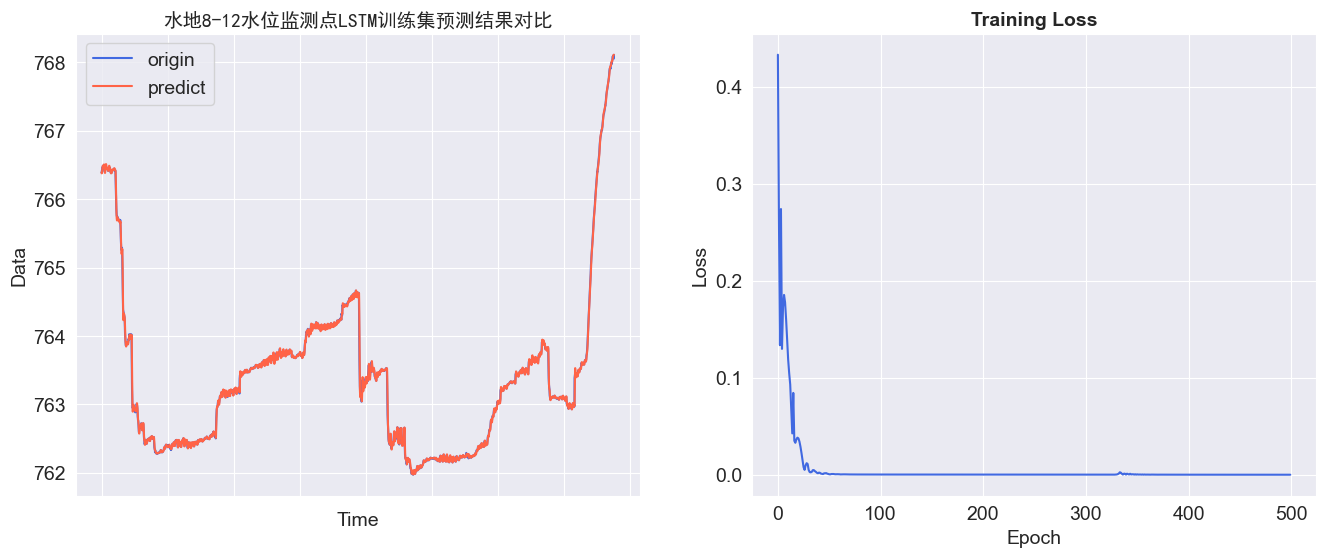

In [11]:
y_train = pd.DataFrame(y_train)
y_train_pred = pd.DataFrame(y_train_pred)

# 模型结果可视化
sns.set_style("darkgrid")
fig = plt.figure()
fig.subplots_adjust(hspace=0.2,wspace=0.2)
plt.subplot(1,2,1)
ax = sns.lineplot(x=y_train.index,y=y_train[0],label="origin",color='royalblue')
ax = sns.lineplot(x=y_train_pred.index,y=y_train_pred[0],label="predict",color='tomato')
ax.set_title(f'水地8-12水位监测点LSTM训练集预测结果对比',size=14,fontweight='bold',fontfamily=["SimHei"])
ax.set_xlabel("Time",size=14)
ax.set_ylabel("Data",size=14)
ax.set_xticklabels('',size=10)

plt.subplot(1,2,2)
ax = sns.lineplot(data=hist,color='royalblue')
ax.set_xlabel("Epoch",size=14)
ax.set_ylabel("Loss",size=14)
ax.set_title("Training Loss",size=14,fontweight='bold')
fig.set_figheight(6)
fig.set_figwidth(16)
plt.savefig('./images/水地8-12.png', dpi=300, bbox_inches='tight')

plt.show()